In [55]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.morphology import remove_small_objects

In [56]:
BASE_PATH = "/kaggle/input/raabindata-nucleus-cytoplasm-ground-truths/GrTh"
IMAGE_PATH = os.path.join(BASE_PATH, "Original")
NUCLEUS_GT = os.path.join(BASE_PATH, "Ground Truth")

In [57]:
def dice(pred, gt):
    return 2*np.sum(pred & gt) / (np.sum(pred)+np.sum(gt)+1e-8)

def iou(pred, gt):
    return np.sum(pred & gt) / (np.sum(pred | gt)+1e-8)

In [58]:
results = []
visual_samples = []

In [59]:
def fcm_manual(img, k=3, m=2, max_iter=50, epsilon=1e-5):

    X = img.reshape(-1).astype(np.float64)
    N = X.shape[0]

    # Random membership initialization
    U = np.random.dirichlet(np.ones(k), size=N)

    for _ in range(max_iter):

        U_old = U.copy()

     
        um = U ** m
        centers = (um.T @ X) / (np.sum(um, axis=0) + 1e-8)

        dist = np.abs(X[:, None] - centers[None, :]) + 1e-8

                power = 2 / (m - 1)
        inv_dist = dist ** (-power)
        U = inv_dist / np.sum(inv_dist, axis=1, keepdims=True)

        # Convergence check
        if np.linalg.norm(U - U_old) < epsilon:
            break

    labels = np.argmax(U, axis=1).reshape(img.shape)

    return labels

In [60]:
for cell_type in os.listdir(IMAGE_PATH):

    cell_dir = os.path.join(IMAGE_PATH, cell_type)
    if not os.path.isdir(cell_dir):
        continue

    image_files = os.listdir(cell_dir)

    print(f"Processing {cell_type} → {len(image_files)} images")

    for img_name in image_files:

        img_path = os.path.join(cell_dir, img_name)
        gt_path  = os.path.join(NUCLEUS_GT, cell_type, img_name)

        if not os.path.exists(gt_path):
            continue


Processing Monocyte → 242 images
Processing Neutrophil → 242 images
Processing Basophil → 218 images
Processing Lymphocyte → 242 images
Processing Eosinophil → 201 images


In [61]:
for img_name in image_files:

    img_path = os.path.join(cell_dir, img_name)
    gt_path  = os.path.join(NUCLEUS_GT, cell_type, img_name)

    if not os.path.exists(gt_path):
        continue

   
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (256,256))

    gt = cv2.imread(gt_path, 0)
    gt = cv2.resize(gt, (256,256), interpolation=cv2.INTER_NEAREST)
    gt = (gt > 0).astype(np.uint8)

  
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    a_channel = lab[:,:,1]

In [62]:
    pixels = a_channel.reshape(-1,1).astype(np.float32)

    _, labels, centers = cv2.kmeans(
        pixels,
        3,
        None,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.2),
        5,
        cv2.KMEANS_RANDOM_CENTERS
    )

    labels = labels.reshape(a_channel.shape)

    means = [np.mean(a_channel[labels == i]) for i in range(3)]
    nucleus_cluster = np.argmin(means)

    k_mask = (labels == nucleus_cluster).astype(np.uint8)
    k_mask = remove_small_objects(k_mask.astype(bool), 50).astype(np.uint8)

In [63]:
    f_labels = fcm_manual(a_channel, k=3, m=2, max_iter=50)

    means = [np.mean(a_channel[f_labels == i]) for i in range(3)]
    nucleus_cluster = np.argmin(means)

    f_mask = (f_labels == nucleus_cluster).astype(np.uint8)
    f_mask = remove_small_objects(f_mask.astype(bool), 50).astype(np.uint8)

In [64]:
        dice_k = dice(k_mask, gt)
        dice_f = dice(f_mask, gt)

        iou_k = iou(k_mask, gt)
        iou_f = iou(f_mask, gt)

        results.append([cell_type, dice_k, dice_f, iou_k, iou_f])

        
        if len(visual_samples) < 8:
            visual_samples.append((image, gt, k_mask, f_mask))

In [66]:
df = pd.DataFrame(results, columns=[
    "Cell Type",
    "KM Dice",
    "FCM Dice",
    "KM IoU",
    "FCM IoU"
])

print("\nPer-Class Average:")
print(df.groupby("Cell Type").mean(numeric_only=True))

print("\nOverall Average:")
print(df.mean(numeric_only=True))


Per-Class Average:
             KM Dice  FCM Dice    KM IoU   FCM IoU
Cell Type                                         
Eosinophil  0.046004  0.046004  0.023544  0.023544

Overall Average:
KM Dice     0.046004
FCM Dice    0.046004
KM IoU      0.023544
FCM IoU     0.023544
dtype: float64


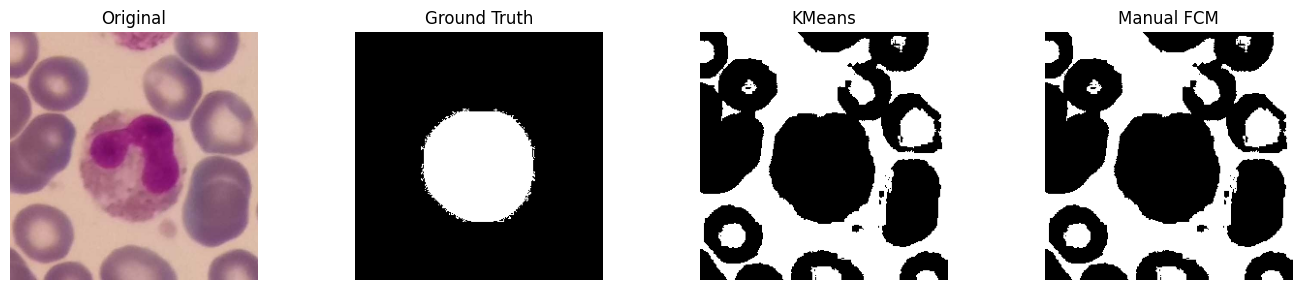

In [67]:
plt.figure(figsize=(14, len(visual_samples)*3))

for i, (img, gt, km, fcm) in enumerate(visual_samples):

    plt.subplot(len(visual_samples),4,4*i+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(len(visual_samples),4,4*i+2)
    plt.imshow(gt, cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(len(visual_samples),4,4*i+3)
    plt.imshow(km, cmap='gray')
    plt.title("KMeans")
    plt.axis('off')

    plt.subplot(len(visual_samples),4,4*i+4)
    plt.imshow(fcm, cmap='gray')
    plt.title("Manual FCM")
    plt.axis('off')

plt.tight_layout()
plt.show()